# Band structure from the local value of the strain — Pryor 1998, Fig. 2

Reproduces Fig. 2 of C. Pryor, *Phys. Rev. B* **57**, 7190 (1998) (preprint
[arXiv:cond-mat/9710304](https://arxiv.org/abs/cond-mat/9710304)), whose caption reads
verbatim:

> **FIG. 2.** Band structure based on the local value of the strain. (a) Bands along the 001
> direction, through the center of the island. (b) Bands Along the 100 direction, through the
> base of the island.

and whose Sec. IV defines the construction and the island size:

> "Fig. 2 shows the band energies computed using the local value of the strain (i.e. the
> eigenvalues of Eq. 4 with $\vec k = 0$). Since the coupling between conduction and valence
> bands is proportional to $\vec k$, for $\vec k = 0$ the model reduces to a six-band model
> with a decoupled conduction band. The bands are shown for an island with $b = 10$ nm."

**Note $b = 10$ nm**, not the $b = 14$ nm used for the bound-state benchmarks elsewhere in this
package.

## What "the eigenvalues of $H_s$ at $k=0$" means concretely

Pryor's Hamiltonian is $H_k + H_s$. His Eq. (5) defines the strain entries

$$p = a_v(e_{xx}+e_{yy}+e_{zz}),\qquad q = b\left[e_{zz}-\tfrac12(e_{xx}+e_{yy})\right],$$
$$r = \tfrac{\sqrt3}{2}b\,(e_{xx}-e_{yy}) - i\,d\,e_{xy},\qquad s = -d(e_{xz}-i e_{yz}),$$

plus the interband terms $u,v$, which carry a derivative and so **vanish at $k=0$**. That is
exactly why the problem factorizes at $k=0$ into a closed-form conduction band plus a $6\times6$
valence block.

Our `kp_pryor.bir_pikus_terms` returns $Q_\varepsilon, R_\varepsilon, S_\varepsilon$ that are
character-for-character Pryor's $q, r, s$ — this is now a direct textual comparison against the
preprint, not an inference. `kp_pryor.local_band_edges` assembles and diagonalizes that block.

In [1]:
import os, sys
sys.path.insert(0, os.getcwd())
import numpy as np
import matplotlib.pyplot as plt

import qdsolver_core as qd
import strain_fourier as sf
import kp_pryor as kp
import pryor1998 as pr

BASE, H, N = 10.0, 0.5, 129          # b = 10 nm island; N odd so z = 0 is exactly a grid point
dot, matrix = pr.PRYOR_TABLE_I['InAs'], pr.PRYOR_TABLE_I['GaAs']
eps_star = qd.eigenstrain(dot['a0'], matrix['a0'])
GaAs_CB = matrix['E_vbo'] + matrix['Eg']     # 1.519 eV, the energy zero's conduction edge
print(f"eigenstrain {eps_star:+.5f},  energy zero = unstrained GaAs valence edge")

eigenstrain -0.06687,  energy zero = unstrained GaAs valence edge


## Grid, mask, strain

The geometry guards are **asserted**, not inspected. A pyramid mask built on a naively
constructed axis came out mirror-asymmetric and 14% undersized earlier in this work, and the
symptom appeared far downstream as a spurious symmetry violation. `centered_axis` is symmetric
by construction; `mirror_asymmetry` must be exactly 0.

In [2]:
cx = qd.centered_axis(N, H)
X, Y, Z = np.meshgrid(cx, cx, cx, indexing='ij')
pyr = qd.pyramid_mask(X, Y, Z, BASE)

assert qd.mirror_asymmetry(pyr, 0) == 0 and qd.mirror_asymmetry(pyr, 1) == 0
i0 = N // 2
assert abs(cx[i0]) < 1e-12          # the coordinate 0.0 is a grid point

strain = sf.solve_strain(pyr, eps_star, matrix['C11'], matrix['C12'], matrix['C44'], H)
g = strain.at(pyr)
print(f"grid {N}^3 @ h={H} nm (span {N*H:.0f} nm), fill fraction {pyr.mean():.2e}")
print(f"  mask volume error {qd.mask_volume_error(pyr, H, BASE**2*(BASE/2)/3):+.4f}")
print(f"  clamping residual {sf.padding_report(strain, pyr):.4f}")
print(f"  <Tr eps> in dot {g['exx']+g['eyy']+g['ezz']:+.5f}, "
      f"biaxial {g['exx']+g['eyy']-2*g['ezz']:+.5f}")

grid 129^3 @ h=0.5 nm (span 64 nm), fill fraction 6.20e-04
  mask volume error -0.0025
  clamping residual 0.0015
  <Tr eps> in dot -0.08779, biaxial -0.10237


## Local band edges

Everything below goes through one helper. Two independent checks come for free:

* **Kramers degeneracy.** At $k=0$ every level must be exactly doubly degenerate for *any*
  strain. Nothing in the code enforces this, so the residual is a real test of the assembled
  block.
* **Two routes to the hydrostatic shift.** Either start from unstrained band edges and let
  `local_band_edges` apply $\pm a\,\mathrm{Tr}\,\varepsilon$, or pass the already-shifted
  fields from `pryor1998.band_edge_fields` with `hydrostatic_applied=True`. These must agree
  exactly — this is the double-counting trap that `include_hydrostatic` exists to guard.

In [3]:
def bands_on(index):
    """Local k=0 band energies along a 1D cut through the grid."""
    sub = sf.StrainTensor(*[getattr(strain, k)[index] for k in sf.StrainTensor.__slots__])
    m = pyr[index]
    pick = lambda key: np.where(m, dot[key], matrix[key])
    Ev = np.where(m, dot['E_vbo'], matrix['E_vbo'])
    return kp.local_band_edges(sub, Ev=Ev, Ec=Ev + pick('Eg'), delta_so=pick('delta_so'),
                               a_c=pick('a_c'), a_v=pick('a_v'), b=pick('b'), d=pick('d'))

cut001 = (i0, i0, slice(None))
b001 = bands_on(cut001)

Ve_f, Vh_f, _, _ = pr.band_edge_fields(pyr, strain.trace)
sub = sf.StrainTensor(*[getattr(strain, k)[cut001] for k in sf.StrainTensor.__slots__])
pre = kp.local_band_edges(sub, Ev=Vh_f[cut001], Ec=Ve_f[cut001],
                          delta_so=np.where(pyr[cut001], dot['delta_so'], matrix['delta_so']),
                          a_c=0.0, a_v=0.0,
                          b=np.where(pyr[cut001], dot['b'], matrix['b']),
                          d=np.where(pyr[cut001], dot['d'], matrix['d']),
                          hydrostatic_applied=True)
print(f"Kramers degeneracy residual        {b001['kramers']:.2e} eV")
print(f"unstrained-edges vs pre-shifted    "
      f"{max(np.abs(b001[k]-pre[k]).max() for k in ('cb','v1','v2','v3')):.2e} eV")

Kramers degeneracy residual        3.33e-16 eV
unstrained-edges vs pre-shifted    0.00e+00 eV


## Fig. 2 — the replica

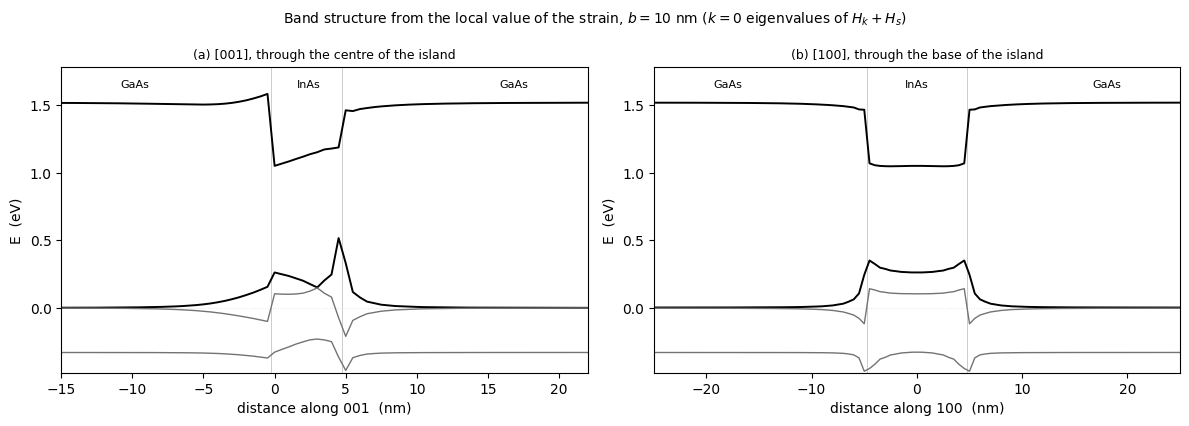

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
cuts = [((i0, i0, slice(None)), cx, 'distance along 001  (nm)', (-15, 22),
         '(a) [001], through the centre of the island'),
        ((slice(None), i0, i0), cx, 'distance along 100  (nm)', (-25, 25),
         '(b) [100], through the base of the island')]

for ax, (cut, axis, xlabel, xlim, title) in zip(axes, cuts):
    bb = bands_on(cut)
    ax.plot(axis, bb['cb'], 'k-', lw=1.4)
    ax.plot(axis, bb['v1'], 'k-', lw=1.4)
    ax.plot(axis, bb['v2'], '-', color='0.45', lw=1.0)
    ax.plot(axis, bb['v3'], '-', color='0.45', lw=1.0)

    for e in np.flatnonzero(np.diff(pyr[cut].astype(int))):
        ax.axvline((axis[e] + axis[e+1]) / 2, color='0.8', lw=0.7, zorder=0)
    ax.axhline(0.0, color='0.9', lw=0.7, ls=':', zorder=0)
    ax.set(xlim=xlim, ylim=(-0.48, 1.78), xlabel=xlabel, ylabel='E  (eV)')
    ax.set_title(title, fontsize=9)
    span = xlim[1] - xlim[0]
    ax.text(xlim[0] + 0.14*span, 1.63, 'GaAs', ha='center', fontsize=8)
    ax.text(xlim[1] - 0.14*span, 1.63, 'GaAs', ha='center', fontsize=8)

axes[0].text(2.4, 1.63, 'InAs', ha='center', fontsize=8)
axes[1].text(0.0, 1.63, 'InAs', ha='center', fontsize=8)
fig.suptitle('Band structure from the local value of the strain, $b=10$ nm '
             r'($k=0$ eigenvalues of $H_k+H_s$)', fontsize=10)
fig.tight_layout()
plt.show()

## Checking it against what Pryor says about this figure

His Sec. IV makes four statements about Fig. 2. All four are checked numerically below rather
than eyeballed — three are qualitative and one is quantitative.

In [5]:
z = cx
in001 = pyr[i0, i0, :]
idx = np.where(in001)[0]
depth = GaAs_CB - b001['cb']

print("1. 'a potential well 0.4 eV deep at the base of the island, tapering to 0.27 eV at the tip'")
print(f"   ours: base {depth[np.argmin(np.abs(z))]:.3f} eV, tip {depth[idx[-1]]:.3f} eV"
      f"   (Pryor 0.40 / 0.27)")

v = b001['v1'][idx]
print("\n2. 'the valence band is peaked near the tip of the island, with another high point")
print("    near the base and a band crossing in between'")
print(f"   ours: base {v[0]:.3f}, dip {v.min():.3f} at z={z[idx][np.argmin(v)]:.1f} nm, "
      f"tip {v[-1]:.3f} eV  -> {'peak-dip-peak: yes' if v.min() < min(v[0], v[-1]) else 'NO'}")

full = kp.local_band_edges(strain,
    Ev=np.where(pyr, dot['E_vbo'], matrix['E_vbo']),
    Ec=np.where(pyr, dot['E_vbo']+dot['Eg'], matrix['E_vbo']+matrix['Eg']),
    delta_so=np.where(pyr, dot['delta_so'], matrix['delta_so']),
    a_c=np.where(pyr, dot['a_c'], matrix['a_c']),
    a_v=np.where(pyr, dot['a_v'], matrix['a_v']),
    b=np.where(pyr, dot['b'], matrix['b']), d=np.where(pyr, dot['d'], matrix['d']))
v1 = full['v1']
print("\n3. 'inside the island the valence-band edge is even higher [than in the barrier].")
print("    Hence we do not expect holes to be trapped in the barrier material'")
print(f"   ours: max inside {v1[pyr].max():.4f} eV vs max in barrier {v1[~pyr].max():.4f} eV"
      f"  -> {'holes stay in the dot' if v1[pyr].max() > v1[~pyr].max() else 'BARRIER TRAP'}")

cut100 = (slice(None), i0, i0)
vb = bands_on(cut100)['v1']
inb = np.where(pyr[cut100])[0]
print("\n4. 'a slight peak in the valence band at the edge of the base' (Fig. 2b)")
print(f"   ours: at base edge {vb[inb[0]]:.4f} eV vs at base centre {vb[i0]:.4f} eV"
      f"  -> {'edge peak: yes' if vb[inb[0]] > vb[i0] else 'NO'}")

1. 'a potential well 0.4 eV deep at the base of the island, tapering to 0.27 eV at the tip'
   ours: base 0.468 eV, tip 0.332 eV   (Pryor 0.40 / 0.27)

2. 'the valence band is peaked near the tip of the island, with another high point
    near the base and a band crossing in between'
   ours: base 0.262, dip 0.151 at z=3.0 nm, tip 0.517 eV  -> peak-dip-peak: yes



3. 'inside the island the valence-band edge is even higher [than in the barrier].
    Hence we do not expect holes to be trapped in the barrier material'
   ours: max inside 0.5165 eV vs max in barrier 0.4220 eV  -> holes stay in the dot

4. 'a slight peak in the valence band at the edge of the base' (Fig. 2b)
   ours: at base edge 0.3506 eV vs at base centre 0.2618 eV  -> edge peak: yes


## The band crossing, made explicit

Pryor's "band crossing in between" is a crossing of *character*, not of energy: $R_\varepsilon$
and $S_\varepsilon$ mix heavy hole with light hole wherever the shear strain is nonzero, so the
levels repel rather than intersect and the topmost one changes what it is made of. Plotting the
basis-state weights of `v1` alongside the energies shows this directly.

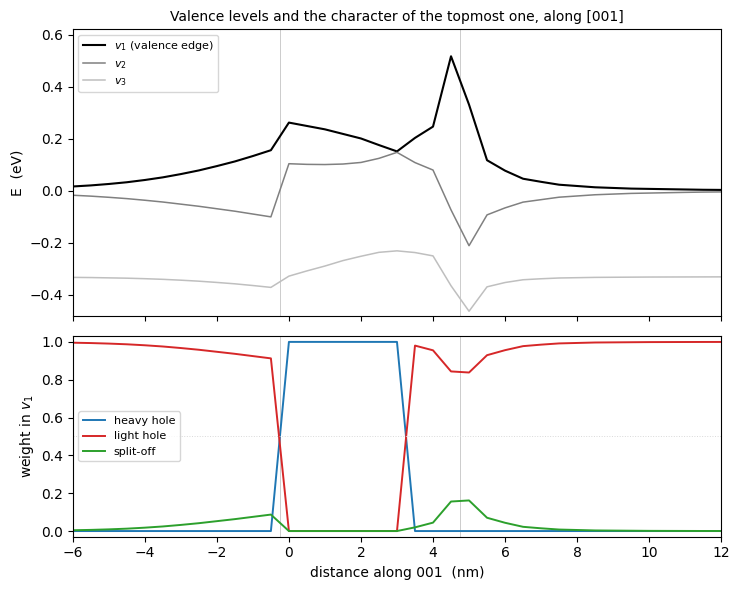

heavy-hole weight in v1 across the island: 0.00 -> 1.00  (sweeping through 0.5 is the crossing)


In [6]:
ch = kp.local_band_character(sub,
    Ev=np.where(in001, dot['E_vbo'], matrix['E_vbo']),
    delta_so=np.where(in001, dot['delta_so'], matrix['delta_so']),
    a_v=np.where(in001, dot['a_v'], matrix['a_v']),
    b=np.where(in001, dot['b'], matrix['b']),
    d=np.where(in001, dot['d'], matrix['d']))

fig, (a1, a2) = plt.subplots(2, 1, figsize=(7.5, 6), sharex=True,
                             gridspec_kw=dict(height_ratios=[2, 1.4]))
a1.plot(z, b001['v1'], 'k-', lw=1.5, label='$v_1$ (valence edge)')
a1.plot(z, b001['v2'], '-', color='0.5', lw=1.1, label='$v_2$')
a1.plot(z, b001['v3'], '-', color='0.75', lw=1.1, label='$v_3$')
a1.set(ylabel='E  (eV)', ylim=(-0.48, 0.62))
a1.legend(fontsize=8, loc='upper left')
a1.set_title('Valence levels and the character of the topmost one, along [001]', fontsize=10)

for k, (lbl, col) in enumerate(zip(['heavy hole', 'light hole', 'split-off'],
                                   ['C0', 'C3', 'C2'])):
    a2.plot(z, ch[:, 0, k], color=col, lw=1.4, label=lbl)
a2.axhline(0.5, color='0.85', lw=0.7, ls=':')
a2.set(xlim=(-6, 12), ylim=(-0.03, 1.03), xlabel='distance along 001  (nm)',
       ylabel='weight in $v_1$')
a2.legend(fontsize=8, loc='center left')

for ax in (a1, a2):
    for e in np.flatnonzero(np.diff(in001.astype(int))):
        ax.axvline((z[e] + z[e+1]) / 2, color='0.8', lw=0.7, zorder=0)
fig.tight_layout()
plt.show()

sw = ch[np.where(in001)[0], 0, 0]
print(f"heavy-hole weight in v1 across the island: {sw.min():.2f} -> {sw.max():.2f}"
      f"  (sweeping through 0.5 is the crossing)")

## A payoff: the correct shift-invert target for hole solves

This calculation settles a question left open earlier. `kp_pryor.hole_sigma` supplies the
target $\sigma$ for a folded-spectrum hole solve, which returns the eigenvalues *nearest*
$\sigma$ — a $\sigma$ placed below the states of interest gives converged, residual-certified,
**wrong** answers.

An earlier version approximated the local valence edge by the heavy-hole diagonal element alone,
$E_v - Q_\varepsilon$. That is not the edge: unlike the kinetic $R$ and $S$, the strain terms
$R_\varepsilon$ and $S_\varepsilon$ do **not** vanish at $k=0$, so they mix the levels and push
the true edge higher. `hole_sigma` now returns the exact $k=0$ edge — the same quantity plotted
above as `v1`.

In [7]:
Qe, _, _ = kp.bir_pikus_terms(strain, np.where(pyr, dot['b'], matrix['b']),
                              np.where(pyr, dot['d'], matrix['d']))
old = float((Vh_f - np.real(Qe))[pyr].max())
new = kp.hole_sigma(Vh_f, strain, np.where(pyr, dot['b'], matrix['b']),
                    np.where(pyr, dot['d'], matrix['d']),
                    np.where(pyr, dot['delta_so'], matrix['delta_so']), inside_mask=pyr)
print(f"E_v - Q_eps alone (old)   {old:.4f} eV")
print(f"hole_sigma (exact k=0)    {new:.4f} eV")
print(f"exact edge from this plot {float(v1[pyr].max()):.4f} eV")
print(f"\n-> the old approximation put sigma {1e3*(v1[pyr].max()-old):.1f} meV too LOW,"
      f" which is the direction that fails silently.")

E_v - Q_eps alone (old)   0.3144 eV
hole_sigma (exact k=0)    0.5165 eV
exact edge from this plot 0.5165 eV

-> the old approximation put sigma 202.2 meV too LOW, which is the direction that fails silently.


## Where this differs from Pryor's calculation

The conduction well comes out **deeper than his at both ends** — 0.47 vs 0.40 eV at the base,
0.33 vs 0.27 eV at the tip. The natural suspect is our homogeneous-elasticity approximation:
`strain_fourier.solve_strain` is a Fourier solve and so requires one set of elastic constants,
whereas Pryor relaxes with each material's own via conjugate gradient. InAs is ~30% softer than
GaAs, so the two choices should bracket him.

They do not — checked below rather than assumed. Both choices give a well *deeper* than his, and
using the softer InAs constants makes the discrepancy worse, not better. So this is not a
stiffness-choice effect that a better single choice would fix; capturing it needs the genuinely
inhomogeneous relaxation. Everything else in this notebook agrees with him, including the sign,
shape and ordering of every feature, so the residual is a known, bounded approximation rather
than an unexplained discrepancy.

Also not included here, deliberately: the piezoelectric potential. Pryor notes it is added to
the full Hamiltonian, but Fig. 2 is defined as the $k=0$ eigenvalues of $H_s$, so it does not
enter this figure. (It could not affect panel (a) in any case — the $[001]$ axis is invariant
under $C_4$ while the piezoelectric potential is $C_4$-antisymmetric, so $\phi \equiv 0$
along it.)

In [8]:
for label in ('GaAs', 'InAs'):
    m = pr.PRYOR_TABLE_I[label]
    s2 = sf.solve_strain(pyr, eps_star, m['C11'], m['C12'], m['C44'], H)
    sub2 = sf.StrainTensor(*[getattr(s2, k)[cut001] for k in sf.StrainTensor.__slots__])
    pick = lambda key: np.where(in001, dot[key], matrix[key])
    Ev = np.where(in001, dot['E_vbo'], matrix['E_vbo'])
    bb = kp.local_band_edges(sub2, Ev=Ev, Ec=Ev + pick('Eg'), delta_so=pick('delta_so'),
                             a_c=pick('a_c'), a_v=pick('a_v'), b=pick('b'), d=pick('d'))
    dep = GaAs_CB - bb['cb']
    t = s2.at(pyr)
    print(f"C from {label}:  <Tr eps> {t['exx']+t['eyy']+t['ezz']:+.5f}   "
          f"well depth  base {dep[np.argmin(np.abs(z))]:.3f}  tip {dep[idx[-1]]:.3f} eV")
print(f"{'Pryor:':<12} inhomogeneous relaxation      "
      f"well depth  base 0.400  tip 0.270 eV")

C from GaAs:  <Tr eps> -0.08779   well depth  base 0.468  tip 0.332 eV


C from InAs:  <Tr eps> -0.07787   well depth  base 0.540  tip 0.377 eV
Pryor:       inhomogeneous relaxation      well depth  base 0.400  tip 0.270 eV
